In [1]:
include("dependencies.jl")
include("system_params.jl")
include("functions.jl")
const Ω, γ_Decay, γ_dephase, V_nn, δ, Δ1_0, T_optimal = unpack_params()

(1.0, 0.001, 0.0, -1000.0, 0.108, 1032.0, 582.0)

In [4]:
basis = NLevelBasis(2)
n = transition(basis,2,2)
σx = transition(basis,1,2) + transition(basis,2,1)

σx_a = full_operator(σx, total_qubits, [1])
σx_b = full_operator(σx, total_qubits, [2])
σx_c = full_operator(σx, total_qubits, [3])

n_a = full_operator(n,total_qubits, [1])
n_c = full_operator(n, total_qubits, [3])

nn_ab = full_operator(n, total_qubits, [1,2])
nn_bc = full_operator(n, total_qubits, [2,3])

p = qubit_parameters(Ω,γ_Decay,γ_dephase,V_nn,δ)

const coeff = [t->get_qubit_parameters(p,t,:T1)]

1-element Vector{var"#19#20"}:
 #19 (generic function with 1 method)

In [5]:
tspan = [0.0:1:10.0;]
const H_t = LazySum([coeff[1](tspan[1])[i] for i ∈ 1:5],[σx_a,σx_b,σx_c])

LazySum(dim=8x8)
  basis: [NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2)]
  operators: 5

In [14]:
function Ht(t,ψ)
    for i=1:length(H_t.factors)
        H_t.factors[i] = coeff[1](t)[i]
    end
    return H_t
end

ψ0 = initialize_system()
full_basis = CompositeBasis([NLevelBasis(2) for _ in 1:total_qubits]...)
ψ0_ket = Ket(full_basis, ComplexF64.(ψ0));

In [16]:
Ht(0.0,ψ0_ket)

LazySum(dim=8x8)
  basis: [NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2)]
  operators: 5

In [9]:
coeff[1](0.0)[1]

1032.0

In [6]:
H_t.factors[1]

1032.0 + 0.0im

In [45]:
using Pkg
Pkg.precompile()

using Plots, JLD2, LaTeXStrings, FileIO
using QuantumOptics
@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/driving_abc_atoms/γ_decay=0.001_Ntraj=1_trial.jld2"

population_a = population_a
population_c = population_c
population_ac = population_ac;

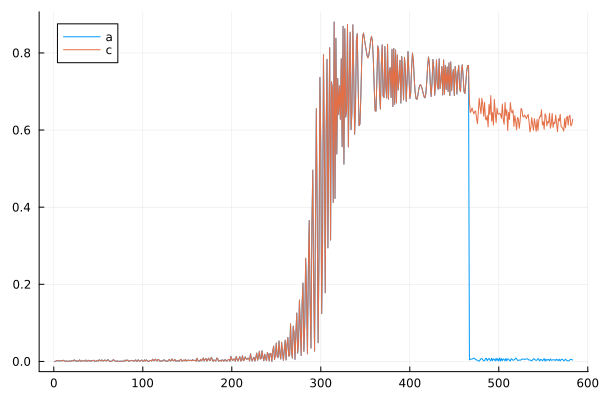

In [34]:
plot(population_a, label="a")
plot!(population_c, label="c")

In [46]:
using Pkg
Pkg.precompile()

using Plots, JLD2, LaTeXStrings, FileIO
using QuantumOptics
@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/driving_abc_atoms/γ_decay=0.001_Ntraj=1_trial.jld2"

population_a = population_a
population_c = population_c
population_ac = population_ac;

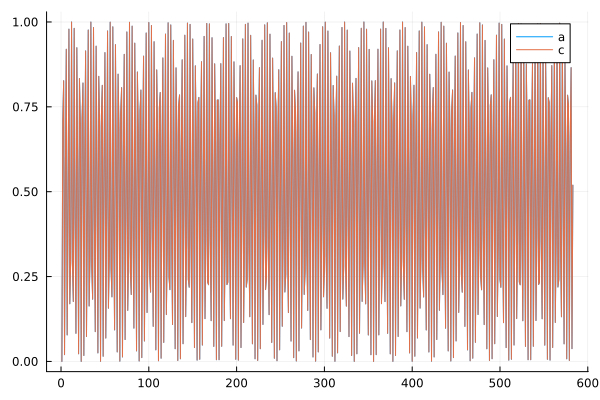

In [ ]:
plot(population_a, label="a")
plot!(population_c, label="c")

In [39]:
log2(1/2)/log2(3/4)

2.409420839653209

In [40]:
5^2.4

47.59134846789696

In [32]:
5* 1e7 /(60*60*24)

215.27777777777777